### Affine + TPS Registration

In [ ]:
# !pip install numpy matplotlib requests opencv-python
# !pip install git+https://github.com/cvg/LightGlue.git
!pip install scipy scikit-image
!pip install -r requirements.txt

In [5]:
! pwd

/home/candano/DSA-Tissue-Reg


#### DownloaD Thumbnails

Thumbnail saved to: /home/candano/DSA-Tissue-Reg/temp3/thumbnail_695e74728c871f3a0296c2e7.png


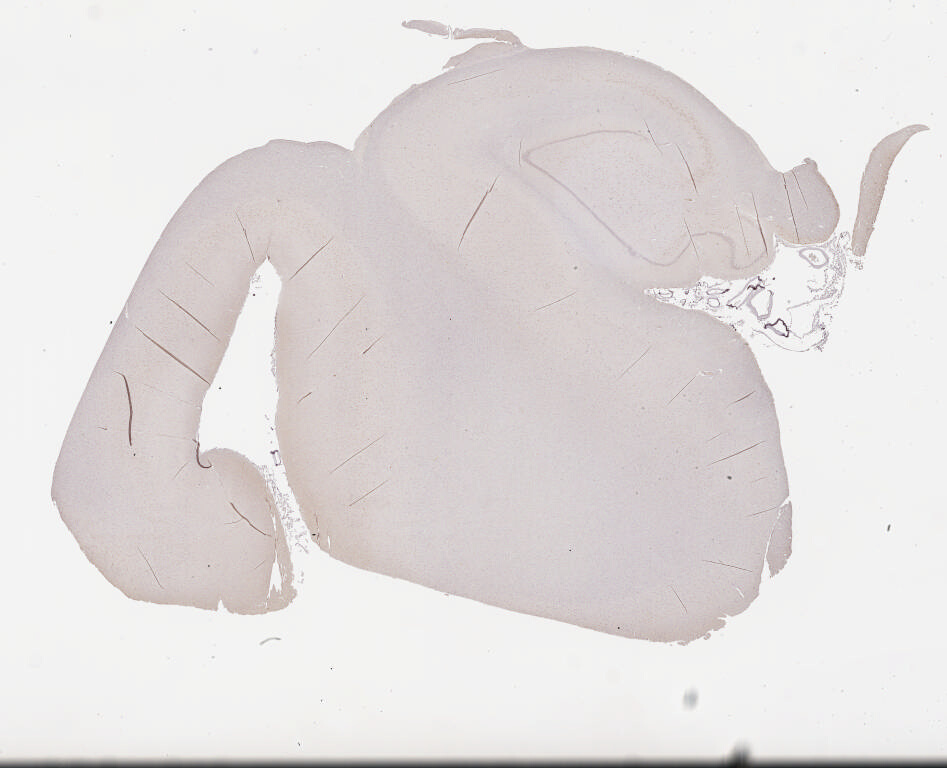

In [ ]:
from girder_client import GirderClient
from PIL import Image
import io
# -----------------------------------------------------------------------------
gc = GirderClient(apiUrl="http://bdsa.pathology.emory.edu:8080/api/v1")
_ = gc.authenticate("admin", "BmiBl0wz!", interactive=False) 
item_id = "695e74748c871f3a0296c315"

# http://bdsa.pathology.emory.edu:8080/#item/
#
#
#
#

# # Correct endpoint path: item/{itemId}/tiles/images/thumbnail
# When jsonResp=False, gc.get() returns a Response object, so we need to access .content
thumbnail_response = gc.get(f"item/{item_id}/tiles/images/thumbnail", jsonResp=False)
thumbnail_data = thumbnail_response.content  # Get the binary data from the response

fname = "/home/candano/DSA-Tissue-Reg/temp4"
os.makedirs(fname, exist_ok=True)
# Option 1: Save to file
output_path = f"{fname}/thumbnail_{item_id}.png"
with open(output_path, 'wb') as f:
    f.write(thumbnail_data)
print(f"Thumbnail saved to: {output_path}")
# Option 2: Display in notebook using PIL
thumbnail_image = Image.open(io.BytesIO(thumbnail_data))
display(thumbnail_image)  # This will show the image in Jupyter notebook

# Option 3: Get thumbnail with specific size (if supported by API)
# thumbnail_response = gc.get(f"item/{item_id}/tiles/images/thumbnail", parameters={"width": 512, "height": 512}, jsonResp=False)
# thumbnail_data = thumbnail_response.content

# http://bdsa.pathology.emory.edu:8080/#item/695e746c8c871f3a0296be9e

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
import os
import sys

# IMPORTANT: Set environment variables BEFORE importing backend modules
# The backend uses Docker paths by default, but we're running locally
local_cache_dir = os.path.join(os.getcwd(), '.npCacheDir')
os.environ['CACHE_DIR'] = local_cache_dir  # Override Docker path with local path

# Set DSA configuration if not already set
if 'DSA_BASE_URL' not in os.environ:
    os.environ['DSA_BASE_URL'] = 'http://bdsa.pathology.emory.edu:8080/api/v1'
if 'DSAKEY' not in os.environ:
    os.environ['DSAKEY'] = os.getenv('DSAKEY', '')

# Create local cache directory if it doesn't exist
os.makedirs(local_cache_dir, exist_ok=True)
print(f"✓ Using local cache directory: {local_cache_dir}")

# Add the viteReg/backend directory to path to import registration functions
# Use absolute path to avoid conflicts with app.py in current directory
backend_path = '/home/candano/DSA-Tissue-Reg/viteReg/backend'
if os.path.exists(backend_path):
    # Insert at the beginning to prioritize this path
    if backend_path not in sys.path:
        sys.path.insert(0, backend_path)
    print(f"✓ Added backend path: {backend_path}")
else:
    # Fallback: try relative path from current directory
    current_dir = os.getcwd()
    backend_path = os.path.join(current_dir, 'viteReg', 'backend')
    if os.path.exists(backend_path):
        if backend_path not in sys.path:
            sys.path.insert(0, backend_path)
        print(f"✓ Added backend path (relative): {backend_path}")
    else:
        raise ImportError(f"Could not find backend at {backend_path} or /home/candano/DSA-Tissue-Reg/viteReg/backend")

# Verify we can import from the correct app package
print(f"Python path includes: {[p for p in sys.path if 'viteReg' in p or 'backend' in p]}")

# Now import from the backend app package
# The settings will now use the CACHE_DIR we set above
from app.services.tps_service import register_with_affine_tps
from app.services.dsa_client import get_dsa_client
from app.services.registration_service import get_thumbnail_image
from app.core.config import settings

print(f"✓ Successfully imported registration functions")
print(f"✓ Settings CACHE_DIR: {settings.CACHE_DIR}")

%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 10)


✓ Using local cache directory: /home/candano/DSA-Tissue-Reg/.npCacheDir
✓ Added backend path: /home/candano/DSA-Tissue-Reg/viteReg/backend
Python path includes: ['/home/candano/DSA-Tissue-Reg/viteReg/backend']
✓ Successfully imported registration functions
✓ Settings CACHE_DIR: /home/candano/DSA-Tissue-Reg/.npCacheDir


#### STOP

In [2]:
# Use local image files (no DSA required)
USE_DSA = False  # Set to True to use DSA item IDs instead

if USE_DSA:
    # Option 1: Use DSA item IDs (strings like "695d9f428c871f3a02969d62")
    FIXED_IMAGE_ID = "695d9f428c871f3a02969d62"  # HE (fixed) image
    MOVING_IMAGE_ID = "695d9f428c871f3a02969d60"  # Moving image (e.g., IHC stain)
    
    print(f"Using DSA images:")
    print(f"  Fixed (HE): {FIXED_IMAGE_ID}")
    print(f"  Moving: {MOVING_IMAGE_ID}")
else:
    # Option 2: Use local image files
    FIXED_IMAGE_PATH = "/home/candano/DSA-Tissue-Reg/temp2/thumbnail_695e746d8c871f3a0296bffb.png"
    MOVING_IMAGE_PATH = "/home/candano/DSA-Tissue-Reg/temp2/thumbnail_695e746d8c871f3a0296bff9.png"
    
    print(f"Using local images:")
    print(f"  Fixed: {FIXED_IMAGE_PATH}")
    print(f"  Moving: {MOVING_IMAGE_PATH}")


Using local images:
  Fixed: /home/candano/DSA-Tissue-Reg/temp2/thumbnail_695e746d8c871f3a0296bffb.png
  Moving: /home/candano/DSA-Tissue-Reg/temp2/thumbnail_695e746d8c871f3a0296bff9.png


## Load Images


In [3]:
def load_images_from_dsa(fixed_id: str, moving_id: str, width: int = 1024):
    """Load thumbnail images from DSA"""
    print("Loading images from DSA...")
    fixed_img = get_thumbnail_image(fixed_id, width)
    moving_img = get_thumbnail_image(moving_id, width)
    
    if fixed_img is None:
        raise ValueError(f"Failed to load fixed image: {fixed_id}")
    if moving_img is None:
        raise ValueError(f"Failed to load moving image: {moving_id}")
    
    print(f"Fixed image shape: {fixed_img.shape}")
    print(f"Moving image shape: {moving_img.shape}")
    
    return fixed_img, moving_img

def load_images_from_files(fixed_path: str, moving_path: str):
    """Load images from local files"""
    print("Loading images from local files...")
    fixed_img = np.array(Image.open(fixed_path).convert('RGB'))
    moving_img = np.array(Image.open(moving_path).convert('RGB'))
    
    print(f"Fixed image shape: {fixed_img.shape}")
    print(f"Moving image shape: {moving_img.shape}")
    
    return fixed_img, moving_img

# Load images
if USE_DSA:
    fixed_img, moving_img = load_images_from_dsa(FIXED_IMAGE_ID, MOVING_IMAGE_ID)
else:
    fixed_img, moving_img = load_images_from_files(FIXED_IMAGE_PATH, MOVING_IMAGE_PATH)

# Convert to BGR for OpenCV if needed (thumbnails are usually RGB)
fixed_bgr = cv2.cvtColor(fixed_img, cv2.COLOR_RGB2BGR) if fixed_img.shape[2] == 3 else fixed_img
moving_bgr = cv2.cvtColor(moving_img, cv2.COLOR_RGB2BGR) if moving_img.shape[2] == 3 else moving_img


Loading images from local files...
Fixed image shape: (669, 1024, 3)
Moving image shape: (703, 1024, 3)


#### Display Input Images

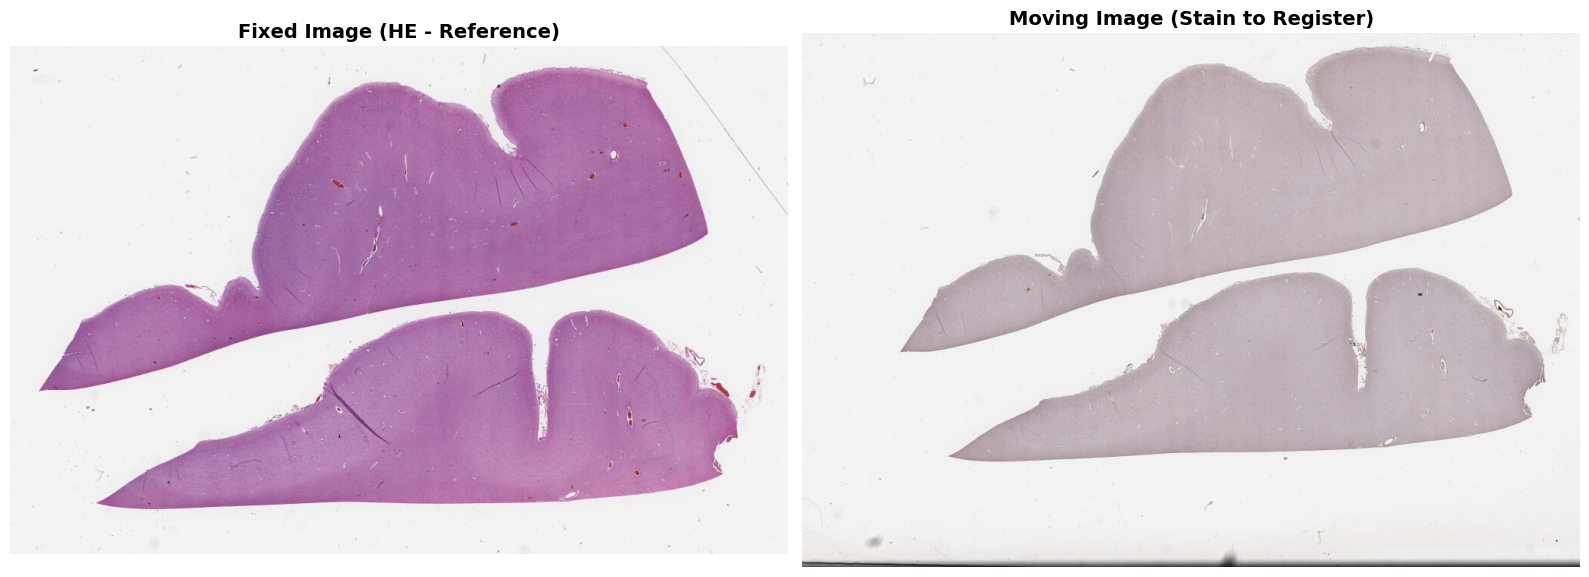

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(fixed_img)
axes[0].set_title('Fixed Image (HE - Reference)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(moving_img)
axes[1].set_title('Moving Image (Stain to Register)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## Perform Affine + TPS Registration

For local images, we'll use a wrapper function that works directly with numpy arrays.


In [ ]:
# Wrapper function to run registration on numpy arrays (local images)
def register_local_images(fixed_img, moving_img, extractor_type="superpoint", max_keypoints=2048):
    """Run Affine + TPS registration on numpy array images"""
    try:
        from lightglue import LightGlue, SuperPoint, DISK, ALIKED, SIFT
        from lightglue.utils import rbd
        import torch
        from torchvision.transforms import ToTensor
    except ImportError:
        raise ImportError("LightGlue is required. Install with: pip install lightglue")
    
    try:
        from scipy.interpolate import RBFInterpolator
    except ImportError:
        raise ImportError("scipy is required. Install with: pip install scipy")
    
    # Convert images to the format expected by LightGlue
    # LightGlue expects numpy arrays in RGB format, then converts to torch tensors
    if isinstance(fixed_img, np.ndarray):
        if fixed_img.dtype != np.uint8:
            fixed_img = (fixed_img * 255).astype(np.uint8) if fixed_img.max() <= 1.0 else fixed_img.astype(np.uint8)
        # Ensure RGB format (3 channels)
        if len(fixed_img.shape) == 2:
            fixed_img = cv2.cvtColor(fixed_img, cv2.COLOR_GRAY2RGB)
        elif fixed_img.shape[2] == 4:
            fixed_img = cv2.cvtColor(fixed_img, cv2.COLOR_RGBA2RGB)
    else:
        # Convert PIL to numpy
        fixed_img = np.array(fixed_img.convert('RGB'))
    
    if isinstance(moving_img, np.ndarray):
        if moving_img.dtype != np.uint8:
            moving_img = (moving_img * 255).astype(np.uint8) if moving_img.max() <= 1.0 else moving_img.astype(np.uint8)
        # Ensure RGB format (3 channels)
        if len(moving_img.shape) == 2:
            moving_img = cv2.cvtColor(moving_img, cv2.COLOR_GRAY2RGB)
        elif moving_img.shape[2] == 4:
            moving_img = cv2.cvtColor(moving_img, cv2.COLOR_RGBA2RGB)
    else:
        # Convert PIL to numpy
        moving_img = np.array(moving_img.convert('RGB'))
    
    # Convert numpy arrays to torch tensors for LightGlue
    # LightGlue expects images as torch tensors with shape [3, H, W] and values in [0, 1]
    to_tensor = ToTensor()
    image0 = to_tensor(fixed_img).unsqueeze(0)  # Add batch dimension: [1, 3, H, W]
    image1 = to_tensor(moving_img).unsqueeze(0)
    
    # Initialize extractor and matcher
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if extractor_type == "superpoint":
        extractor = SuperPoint(max_num_keypoints=max_keypoints).eval().to(device)
    elif extractor_type == "disk":
        extractor = DISK(max_num_keypoints=max_keypoints).eval().to(device)
    else:
        extractor = SuperPoint(max_num_keypoints=max_keypoints).eval().to(device)
    
    matcher = LightGlue(features=extractor_type).eval().to(device)
    
    # Extract features and match
    with torch.no_grad():
        feats0 = extractor.extract(image0.to(device))
        feats1 = extractor.extract(image1.to(device))
        matches01 = matcher({"image0": feats0, "image1": feats1})
        feats0, feats1, matches01 = [rbd(x) for x in [feats0, feats1, matches01]]
    
    # Get matched keypoints
    kpts0 = feats0["keypoints"].cpu().numpy()
    kpts1 = feats1["keypoints"].cpu().numpy()
    matches = matches01["matches"].cpu().numpy()
    m_kpts0 = kpts0[matches[matches[:, 0] >= 0, 0]]
    m_kpts1 = kpts1[matches[matches[:, 0] >= 0, 1]]
    
    if len(m_kpts0) < 4:
        return {
            "success": False,
            "error": f"Insufficient matches: {len(m_kpts0)} (need at least 4)"
        }
    
    # Estimate affine transform using RANSAC with OpenCV
    affine_matrix, inliers = cv2.estimateAffinePartial2D(
        m_kpts1.reshape(-1, 1, 2),
        m_kpts0.reshape(-1, 1, 2),
        method=cv2.RANSAC,
        ransacReprojThreshold=3.0,
        maxIters=5000
    )
    
    if affine_matrix is None:
        return {
            "success": False,
            "error": "Failed to estimate affine transform"
        }
    
    inlier_mask = inliers.ravel().astype(bool)
    num_inliers = inlier_mask.sum()
    
    if num_inliers < 30:
        return {
            "success": False,
            "error": f"Insufficient inliers: {num_inliers} (need at least 30 for TPS)"
        }
    
    # Apply affine transform
    # Convert images to BGR for OpenCV operations
    if len(fixed_img.shape) == 3 and fixed_img.shape[2] == 3:
        fixed_bgr = cv2.cvtColor(fixed_img, cv2.COLOR_RGB2BGR)
    else:
        fixed_bgr = fixed_img
    if len(moving_img.shape) == 3 and moving_img.shape[2] == 3:
        moving_bgr = cv2.cvtColor(moving_img, cv2.COLOR_RGB2BGR)
    else:
        moving_bgr = moving_img
    
    h, w = fixed_img.shape[:2]
    warped_affine = cv2.warpAffine(moving_bgr, affine_matrix, (w, h))
    
    # TPS refinement using scipy
    p0_in = m_kpts1[inlier_mask]
    p1_in = m_kpts0[inlier_mask]
    
    # Apply affine to source points
    ones = np.ones((p0_in.shape[0], 1))
    p0_h = np.concatenate([p0_in, ones], axis=1)
    A_3x3 = np.vstack([affine_matrix, [0, 0, 1]])
    p0_aff = (A_3x3 @ p0_h.T).T[:, :2]
    
    # TPS warp using scipy
    from scipy.interpolate import RBFInterpolator
    rbf = RBFInterpolator(
        p0_aff,
        p1_in - p0_aff,  # Displacement vectors
        kernel="thin_plate_spline",
        smoothing=1.0
    )
    
    # Create coordinate grid
    y, x = np.mgrid[0:h, 0:w]
    coords = np.vstack([x.ravel(), y.ravel()]).T
    displacements = rbf(coords)
    warped_coords = coords + displacements
    
    # Reshape for remap
    map_x = warped_coords[:, 0].reshape(h, w).astype(np.float32)
    map_y = warped_coords[:, 1].reshape(h, w).astype(np.float32)
    
    # Apply TPS warp
    warped_tps = cv2.remap(warped_affine, map_x, map_y, cv2.INTER_LINEAR)
    
    # Calculate metrics
    fixed_gray = cv2.cvtColor(fixed_bgr, cv2.COLOR_BGR2GRAY)
    warped_gray = cv2.cvtColor(warped_tps, cv2.COLOR_BGR2GRAY)
    
    # Calculate similarity metrics
    from skimage.metrics import structural_similarity as ssim
    
    # Normalized Cross-Correlation (simplified)
    fixed_flat = fixed_gray.flatten().astype(np.float64)
    warped_flat = warped_gray.flatten().astype(np.float64)
    fixed_norm = (fixed_flat - fixed_flat.mean()) / (fixed_flat.std() + 1e-10)
    warped_norm = (warped_flat - warped_flat.mean()) / (warped_flat.std() + 1e-10)
    ncc = np.mean(fixed_norm * warped_norm)
    
    # Structural Similarity Index
    ssim_val = ssim(fixed_gray, warped_gray)
    
    # Calculate Dice coefficient using binary masks (Otsu thresholding)
    def prepare_mask_otsu(image):
        """Create binary mask using Otsu thresholding"""
        # Apply Gaussian blur to reduce noise
        blurred = cv2.GaussianBlur(image, (5, 5), 0)
        # Otsu thresholding
        _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return mask
    
    def pad_to_size(mask, target_size):
        """Pad mask to target square size, centering it"""
        h, w = mask.shape
        pad_height = target_size - h
        pad_width = target_size - w
        pad_top = pad_height // 2
        pad_bottom = pad_height - pad_top
        pad_left = pad_width // 2
        pad_right = pad_width - pad_left
        return np.pad(mask, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant', constant_values=0)
    
    def calculate_dice(mask1, mask2):
        """Calculate Dice coefficient between two binary masks"""
        # Convert to binary (0 or 1)
        mask1_binary = (mask1 > 0).astype(np.uint8)
        mask2_binary = (mask2 > 0).astype(np.uint8)
        
        # Calculate intersection and sizes
        intersection = np.logical_and(mask1_binary, mask2_binary).sum()
        size1 = mask1_binary.sum()
        size2 = mask2_binary.sum()
        
        # Dice coefficient: 2 * intersection / (size1 + size2)
        dice = 2.0 * intersection / (size1 + size2) if (size1 + size2) > 0 else 0.0
        return min(1.0, max(0.0, dice))  # Clamp to [0, 1]
    
    # Create masks from grayscale images
    mask1 = prepare_mask_otsu(fixed_gray)
    mask2 = prepare_mask_otsu(warped_gray)
    
    # Pad masks to same size for comparison
    h1, w1 = mask1.shape
    h2, w2 = mask2.shape
    max_dim = max(h1, w1, h2, w2)
    padded_mask1 = pad_to_size(mask1, max_dim)
    padded_mask2 = pad_to_size(mask2, max_dim)
    
    # Calculate Dice coefficient
    dice = calculate_dice(padded_mask1, padded_mask2)
    
    # Extract transform parameters
    rotation = np.arctan2(affine_matrix[1, 0], affine_matrix[0, 0]) * 180 / np.pi
    scale = np.sqrt(affine_matrix[0, 0]**2 + affine_matrix[1, 0]**2)
    offset_x = affine_matrix[0, 2]
    offset_y = affine_matrix[1, 2]
    
    return {
        "success": True,
        "num_matches": len(m_kpts0),
        "num_inliers": num_inliers,
        "rotation_degrees": float(rotation),
        "scale": float(scale),
        "offset_x": float(offset_x),
        "offset_y": float(offset_y),
        "transform_matrix": A_3x3.tolist(),
        "normalized_cross_correlation": float(ncc),
        "structural_similarity": float(ssim_val),
        "dice_coefficient": dice,
        "warped_image": warped_tps,
        "warped_affine": warped_affine
    }

# Run registration
if USE_DSA:
    print("Running Affine + TPS registration (DSA)...")
    result = register_with_affine_tps(
        fixed_id=FIXED_IMAGE_ID,
        moving_id=MOVING_IMAGE_ID,
        extractor_type="superpoint",
        thumbnail_width=1024,
        max_keypoints=2048,
        device=None,
        max_matches_for_tps=2000,
        affine_ransac_thresh_px=3.0,
        affine_max_iters=5000,
        tps_min_inliers=30,
        tps_grid_step=2
    )
else:
    print("Running Affine + TPS registration ...")
    result = register_local_images(fixed_img, moving_img, extractor_type="superpoint", max_keypoints=2048)

# Display results
print("\nRegistration Results:")
print(f"  Success: {result['success']}")
if result['success']:
    print(f"  Matches: {result.get('num_matches', 'N/A')}")
    print(f"  Inliers: {result.get('num_inliers', 'N/A')}")
    print(f"  Rotation: {result.get('rotation_degrees', 0):.2f}°")
    print(f"  Scale: {result.get('scale', 1):.3f}")
    print(f"  Dice Coefficient: {result.get('dice_coefficient', 'N/A')}")
    print(f"  NCC: {result.get('normalized_cross_correlation', 'N/A'):.4f}")
    print(f"  SSIM: {result.get('structural_similarity', 'N/A'):.4f}")
else:
    print(f"  Error: {result.get('error', 'Unknown error')}")


## Visualize Registration Results

For local images, the registration result includes the warped images directly.


In [ ]:
# Prepare registered result image
if result and result['success']:
    if USE_DSA:
        # Get the warped overlay from the API
        api_base_url = "http://localhost:8000/api"  # Adjust if needed
        viz_url = f"{api_base_url}/visualization/warped-overlay/{FIXED_IMAGE_ID}/{MOVING_IMAGE_ID}?method=affine_tps&opacity=0.5&width=1024"
        
        print(f"Loading registered result from: {viz_url}")
        try:
            response = requests.get(viz_url, timeout=30)
            if response.status_code == 200:
                registered_img = np.array(Image.open(BytesIO(response.content)).convert('RGB'))
                print(f"Registered image shape: {registered_img.shape}")
            else:
                print(f"Failed to load registered image: HTTP {response.status_code}")
                registered_img = None
        except Exception as e:
            print(f"Error loading registered image: {e}")
            registered_img = None
    else:
        # For local images, create overlay from warped result
        warped_tps = result.get('warped_image')
        if warped_tps is not None:
            # Convert BGR to RGB
            warped_rgb = cv2.cvtColor(warped_tps, cv2.COLOR_BGR2RGB)
            # Create overlay: fixed (grayscale) + warped (colored) at 50% opacity
            fixed_gray = cv2.cvtColor(fixed_bgr, cv2.COLOR_BGR2GRAY)
            fixed_gray_3ch = cv2.cvtColor(fixed_gray, cv2.COLOR_GRAY2RGB)
            registered_img = (fixed_gray_3ch * 0.5 + warped_rgb * 0.5).astype(np.uint8)
            print(f"Created overlay from local registration result")
        else:
            registered_img = None
else:
    registered_img = None


## Visualize Results


In [ ]:
if registered_img is not None:
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    
    axes[0].imshow(fixed_img)
    axes[0].set_title('Fixed Image (HE - Reference)', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(moving_img)
    axes[1].set_title('Moving Image (Original)', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(registered_img)
    axes[2].set_title('Registered Result (Fixed + Warped Moving Overlay)', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Display registration metrics
    if result and result['success']:
        print("\n" + "="*60)
        print("REGISTRATION METRICS")
        print("="*60)
        print(f"Matches Found: {result.get('num_matches', 'N/A')}")
        print(f"Affine Inliers: {result.get('num_inliers', 'N/A')}")
        print(f"Rotation: {result.get('rotation_degrees', 0):.2f}°")
        print(f"Translation: ({result.get('offset_x', 0):.2f}, {result.get('offset_y', 0):.2f}) px")
        print(f"Scale: {result.get('scale', 1):.4f}")
        if result.get('dice_coefficient') is not None:
            print(f"Dice Coefficient: {result.get('dice_coefficient'):.4f}")
        if result.get('normalized_cross_correlation') is not None:
            print(f"Normalized Cross-Correlation: {result.get('normalized_cross_correlation'):.4f}")
        if result.get('structural_similarity') is not None:
            print(f"Structural Similarity (SSIM): {result.get('structural_similarity'):.4f}")
        print("="*60)
else:
    print("\nCould not load registered result. Please check:")
    print("  1. The registration completed successfully")
    print("  2. The API is running and accessible")
    print("  3. The visualization endpoint is working")


## Alternative: Create Affine-Only Visualization

If the API endpoint is not available, we can create a visualization using just the affine transform (without TPS refinement).


In [ ]:
if result and result['success']:
    # Apply affine transform manually for visualization
    transform_matrix = np.array(result['transform_matrix'])
    
    # Extract affine parameters (2x3 matrix)
    A = transform_matrix[:2, :3]
    
    # Get image dimensions
    h_fixed, w_fixed = fixed_bgr.shape[:2]
    h_moving, w_moving = moving_bgr.shape[:2]
    
    # Warp moving image using affine transform
    warped_moving = cv2.warpAffine(moving_bgr, A, (w_fixed, h_fixed), flags=cv2.INTER_LINEAR)
    
    # Create overlay (note: this is just affine, not full TPS warp)
    # For full TPS warp, we'd need the control points and TPS parameters
    fixed_gray = cv2.cvtColor(fixed_bgr, cv2.COLOR_BGR2GRAY)
    warped_gray = cv2.cvtColor(warped_moving, cv2.COLOR_BGR2GRAY)
    overlay = cv2.addWeighted(fixed_gray, 0.5, warped_gray, 0.5, 0)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    
    axes[0, 0].imshow(fixed_img)
    axes[0, 0].set_title('Fixed Image (HE)', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(moving_img)
    axes[0, 1].set_title('Moving Image (Original)', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(cv2.cvtColor(warped_moving, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title('Affine-Warped Moving Image', fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(overlay, cmap='gray')
    axes[1, 1].set_title('Overlay (Fixed + Affine-Warped Moving)', fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\nNote: This visualization shows the affine transformation only.")
    print("The full Affine + TPS result includes additional non-rigid refinement.")
    print("For the complete TPS-warped result, use the API visualization endpoint.")
else:
    print("Registration was not successful. Cannot create visualization.")
